In [1]:
import os
import random
import shutil
import itertools
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import pwlf
from multiprocessing import Pool, cpu_count
from tqdm import tqdm, trange

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

import brevitas.nn as qnn
from brevitas.nn import QuantLinear, QuantReLU, QuantConv2d
from brevitas.quant.binary import SignedBinaryActPerTensorConst
from brevitas.quant.binary import SignedBinaryWeightPerTensorConst
from brevitas.inject.enum import QuantType
from brevitas.quant_tensor.int_quant_tensor import IntQuantTensor
from brevitas.function.ops_ste import round_ste

from bika import BiKA_Linear, BiKA_Conv2d

GPU_device = "cuda:1"

# Network Definition

In [2]:
kernel_size      = (3,3) 

in_channel_0_0   = 3
out_channel_0_0  = 64 
in_channel_0_1   = out_channel_0_0
out_channel_0_1  = 64 

in_channel_1_0   = out_channel_0_1
out_channel_1_0  = 128
in_channel_1_1   = out_channel_1_0
out_channel_1_1  = 128 

in_channel_2_0   = out_channel_1_1
out_channel_2_0  = 256
in_channel_2_1   = out_channel_2_0
out_channel_2_1  = 256 

input_length     = 4*4*out_channel_2_1

hidden_0         = 512  
hidden_1         = 512   

output_length    = 10 

In [3]:
class CNV(nn.Module):
    def __init__(self, dropout=0.5):
        super(CNV, self).__init__()
        
        self.conv0_0 = BiKA_Conv2d(
                         in_channels=in_channel_0_0,
                         out_channels=out_channel_0_0,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1)
        self.drop0_0 = nn.Dropout2d(dropout)
        
        self.conv0_1 = BiKA_Conv2d( 
                         in_channels=in_channel_0_1,
                         out_channels=out_channel_0_1,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1)
        self.drop0_1 = nn.Dropout2d(dropout)
        
        self.pool0 = nn.MaxPool2d(2)
        
        self.conv1_0 = BiKA_Conv2d( 
                         in_channels=in_channel_1_0,
                         out_channels=out_channel_1_0,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1)
        self.drop1_0 = nn.Dropout2d(dropout)
        
        self.conv1_1 = BiKA_Conv2d( 
                         in_channels=in_channel_1_1,
                         out_channels=out_channel_1_1,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1)
        self.drop1_1 = nn.Dropout2d(dropout)
        
        self.pool1 = nn.MaxPool2d(2)
        
        self.conv2_0 = BiKA_Conv2d( 
                         in_channels=in_channel_2_0,
                         out_channels=out_channel_2_0,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1)
        self.drop2_0 = nn.Dropout2d(dropout)
        
        self.conv2_1 = BiKA_Conv2d( 
                         in_channels=in_channel_2_1,
                         out_channels=out_channel_2_1,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1)
        self.drop2_1 = nn.Dropout2d(dropout)
        
        self.pool2 = nn.MaxPool2d(2)
        
        self.fc3   = BiKA_Linear(
                         input_length, 
                         hidden_0)
        self.drop3 = nn.Dropout(dropout)
        
        self.fc4   = BiKA_Linear(
                         hidden_0, 
                         hidden_1)
        self.drop4 = nn.Dropout(dropout)
        
        self.out   = BiKA_Linear(
                         hidden_1, 
                         output_length)

    def forward(self, x):
        out = self.drop0_0(self.conv0_0(x))
        out = self.drop0_1(self.conv0_1(out))
        out = self.pool0(out)
        
        out = self.drop1_0(self.conv1_0(out))
        out = self.drop1_1(self.conv1_1(out))
        out = self.pool1(out)
        
        out = self.drop2_0(self.conv2_0(out))
        out = self.drop2_1(self.conv2_1(out))
        out = self.pool2(out)
        
        out = out.reshape(out.shape[0], -1)
        out = self.drop3(self.fc3(out))
        out = self.drop4(self.fc4(out))
        out = self.out(out)
        
        return out

# Random Seed Utility

In [4]:
def set_random_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# Define Dataloader

In [5]:
Test_batch_size = 4096

In [6]:
def get_dataloaders(batch_size):
    try:
        # Works if running as a .py script
        project_root = os.path.abspath(os.path.join(os.path.dirname(__file__), ".."))
    except NameError:
        # Works if running in Jupyter (no __file__)
        project_root = os.path.abspath("..")
    
    dataset_root = os.path.join(project_root, "Dataset")
    
    train_dataset = datasets.CIFAR10(   dataset_root, 
                                        train=True, 
                                        download=True, 
                                        transform = transforms.Compose([
                                            transforms.ToTensor(),
                                            transforms.Normalize((0.5, 0.5, 0.5),  # mean for CIFAR-10
                                                                 (0.5, 0.5, 0.5))  # std for CIFAR-10
                                        ])
                                    )
    test_dataset  = datasets.CIFAR10(   dataset_root, 
                                        train=False, 
                                        download=True, 
                                        transform = transforms.Compose([
                                            transforms.ToTensor(),
                                            transforms.Normalize((0.5, 0.5, 0.5),  # mean for CIFAR-10
                                                                 (0.5, 0.5, 0.5))  # std for CIFAR-10
                                        ])
                                    )
    val_size = int(0.2 * len(train_dataset))
    train_size = len(train_dataset) - val_size
    train_set, val_set = random_split(train_dataset, [train_size, val_size])
    return (
        DataLoader(train_set, batch_size=batch_size, shuffle=True),
        DataLoader(val_set, batch_size=batch_size),
        DataLoader(test_dataset, batch_size=Test_batch_size),
    )

# Evaluation Pipeline

In [7]:
def evaluate(model, criterion, device, loader, train):
    model.eval()
    loss_total, correct, total = 0, 0, 0
    with torch.no_grad():
        if (train):
            for x, y in loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                loss_total += loss.item() * x.size(0)
                _, pred = out.max(1)
                correct += (pred == y).sum().item()
                total += x.size(0)
        else:
            for x, y in tqdm(loader, desc="Evaluation", leave=True):
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                loss_total += loss.item() * x.size(0)
                _, pred = out.max(1)
                correct += (pred == y).sum().item()
                total += x.size(0)
    return loss_total / total, correct / total

# Plot Training Loss and Accuracy

In [8]:
def plot_train(history, save_dir):
    # Plot and show
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.legend()
    plt.title("Loss")

    plt.subplot(1, 2, 2)
    plt.plot(history["train_acc"], label="Train Acc")
    plt.plot(history["val_acc"], label="Val Acc")
    plt.legend()
    plt.title("Accuracy")
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "training_plot.png"))
    plt.show()

# Training, Validation, and Testing Pipeline

In [9]:
def train_validate_test(config, save_dir):
    set_random_seed()
    os.makedirs(save_dir, exist_ok=True)
    log_file = os.path.join(save_dir, "training_log.txt")
    resume_path = os.path.join(save_dir, "checkpoint.pth")

    epochs, batch_size, lr1, lr2, lr3, dropout = config
    train_loader, val_loader, test_loader = get_dataloaders(batch_size)
    device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
    model = CNV(dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr1)

    start_epoch = 0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    if os.path.exists(resume_path):
        ckpt = torch.load(resume_path)
        model.load_state_dict(ckpt["model_state"])
        model.to(device)
        optimizer.load_state_dict(ckpt["optimizer_state"])
        history = ckpt["history"]
        start_epoch = ckpt["epoch"] + 1
        print(f"🔄 Resuming from epoch {start_epoch}")
    else:
        with open(log_file, "w") as f:
            f.write("Training started\n")

    # Training Loop
    t = trange(start_epoch, epochs, desc="Training", leave=True)
    for epoch in t:
        model.train()
        lr = lr1 if epoch < 0.5 * epochs else lr2 if epoch < 0.8 * epochs else lr3
        for g in optimizer.param_groups:
            g["lr"] = lr

        train_loss, correct, total = 0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * x.size(0)
            _, pred = out.max(1)
            correct += (pred == y).sum().item()
            total += x.size(0)

        val_loss, val_acc = evaluate(model, criterion, device, val_loader, train=True)
        train_loss /= total
        train_acc = correct / total
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        log_line = (f"Epoch {epoch+1}/{epochs} - LR: {lr:.5f} | "
                    f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
                    f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
        #print(log_line)
        with open(log_file, "a") as f:
            f.write(log_line + "\n")

        t.set_description("| LR: %.3f | Train Acc: %.4f | Val Acc: %.4f |" % (lr, train_acc, val_acc))
        t.refresh()

        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "history": history
        }, resume_path)

    # Plot and show the training history
    plot_train(history, save_dir)

    # Test the original trained model
    original_test_loss, original_test_acc = evaluate(model, criterion, device, test_loader, train=False)
    final_line = f"Original Model Final Test Loss: {original_test_loss:.4f} Accuracy: {original_test_acc:.4f}"
    print(final_line)
    with open(log_file, "a") as f:
        f.write("Training completed\n")
        f.write(final_line + "\n")

    # Save the trained model
    torch.save(model.state_dict(), os.path.join(save_dir, "final_model.pth"))
    with open(log_file, "a") as f:
        f.write(final_line + "\n")
    print("\n")

    return original_test_acc

# Hyperparameter Searching for Network Training and Testing

In [10]:
def Hyperparameter_searching(root_path, epochs, batch_sizes, lr_pool, dropout_rates):
    output_root = root_path
    os.makedirs(output_root, exist_ok=True)
    
    epochs = epochs
    batch_sizes = batch_sizes
    lr_pool = lr_pool
    
    # Generate descending LR combinations
    lr_combos = [combo for combo in itertools.product(lr_pool, repeat=3)
                 if (combo[0] > combo[1] > combo[2]) or (combo[0] == combo[1] == combo[2])]
    
    all_runs = [
        f"batch{bs}_lr{lr1}_{lr2}_{lr3}"
        for bs, (lr1, lr2, lr3) in itertools.product(batch_sizes, lr_combos)
    ]
    
    completed_runs = []
    for run in all_runs:
        log_path = os.path.join(output_root, run, "training_log.txt")
        if os.path.exists(log_path):
            with open(log_path, "r") as f:
                if any("Training completed" in line for line in f):
                    completed_runs.append(run)
    
    if len(completed_runs) == len(all_runs):
        print("✅ All combinations completed. Restarting from scratch...")
        for run in all_runs:
            shutil.rmtree(os.path.join(output_root, run), ignore_errors=True)
        if os.path.exists(os.path.join(output_root, "summary.csv")):
            os.remove(os.path.join(output_root, "summary.csv"))
        completed_runs = []
    
    results = []
    for batch_size, (lr1, lr2, lr3), dropout in itertools.product(batch_sizes, lr_combos, dropout_rates):
        run_name = f"batch{batch_size}_lr{lr1}_{lr2}_{lr3}_dp{dropout}"
        save_dir = os.path.join(output_root, run_name)
    
        if run_name in completed_runs:
            print(f"✅ Skipping {run_name}")
            with open(os.path.join(save_dir, "training_log.txt")) as f:
                for line in f:
                    if "Final Test Loss" in line:
                        acc = float(line.strip().split()[-1])
                        results.append((run_name, acc))
            continue
    
        print(f"🚀 Running: {run_name}")
        acc = train_validate_test([epochs, batch_size, lr1, lr2, lr3, dropout], save_dir)
        results.append((run_name, acc))
    
    results.sort(key=lambda x: x[1], reverse=True)
    best_config, best_acc = results[0]
    print(f"🏆 Best Config: {best_config} Accuracy: {best_acc:.4f}")
    
    with open(os.path.join(output_root, "summary.csv"), "w") as f:
        f.write("Config,Accuracy\n")
        for name, acc in results:
            f.write(f"{name},{acc:.4f}\n")

🚀 Running: batch256_lr0.001_0.001_0.001_dp0.0


Files already downloaded and verified


Files already downloaded and verified


🔄 Resuming from epoch 200


Training: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

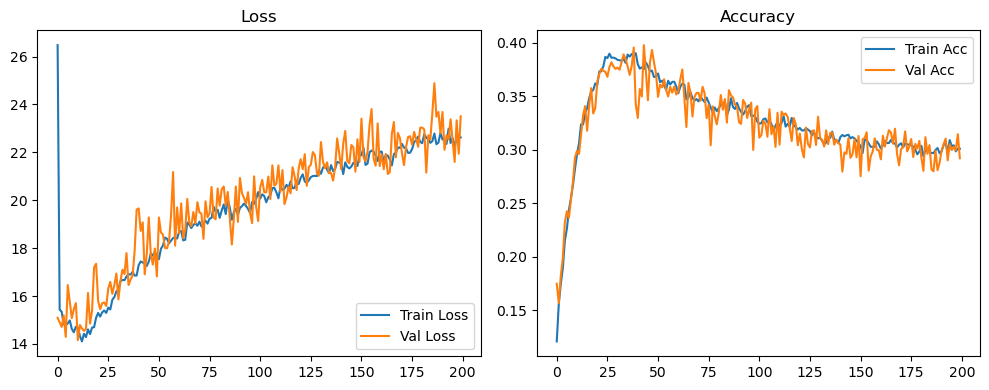

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:02<00:05,  2.54s/it]

Evaluation:  67%|██████▋   | 2/3 [00:05<00:02,  2.55s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  1.90s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  2.07s/it]

...

Files already downloaded and verified


Files already downloaded and verified


🔄 Resuming from epoch 200


Training: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

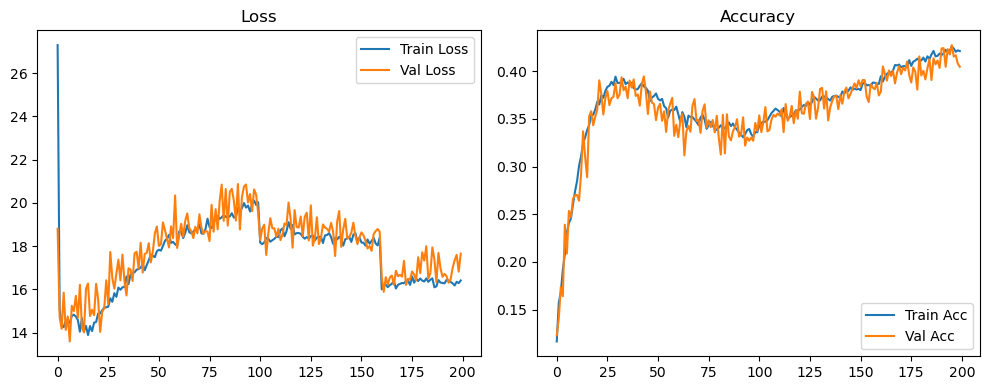

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:02<00:05,  2.53s/it]

Evaluation:  67%|██████▋   | 2/3 [00:05<00:02,  2.54s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  1.90s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  2.07s/it]

...

Files already downloaded and verified


Files already downloaded and verified


🔄 Resuming from epoch 200


Training: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

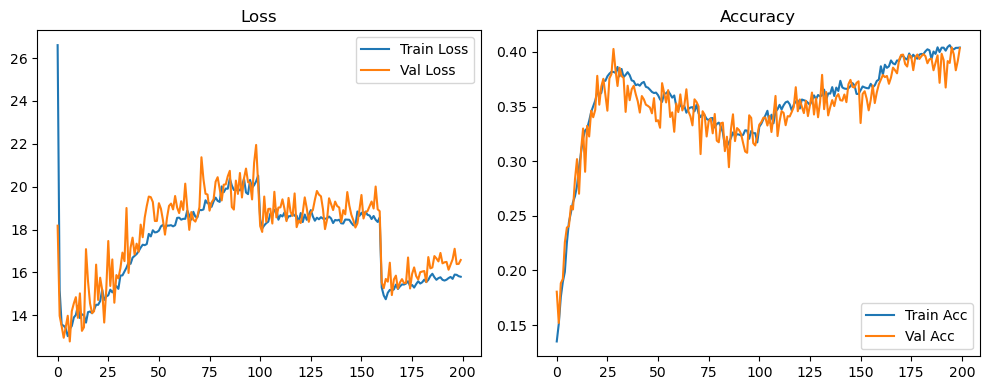

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:02<00:05,  2.53s/it]

Evaluation:  67%|██████▋   | 2/3 [00:05<00:02,  2.62s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  1.94s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  2.11s/it]

...

Files already downloaded and verified


Files already downloaded and verified


🔄 Resuming from epoch 200


Training: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

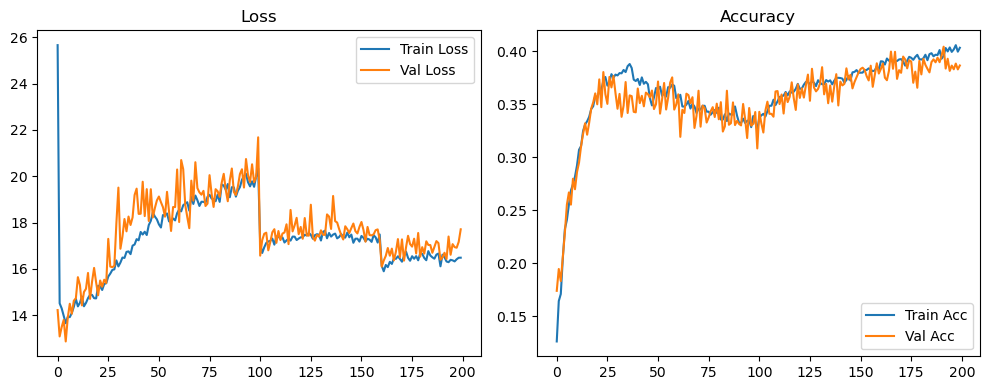

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:02<00:05,  2.52s/it]

Evaluation:  67%|██████▋   | 2/3 [00:05<00:02,  2.52s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  1.88s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  2.05s/it]

...

Files already downloaded and verified


Files already downloaded and verified


🔄 Resuming from epoch 200


Training: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

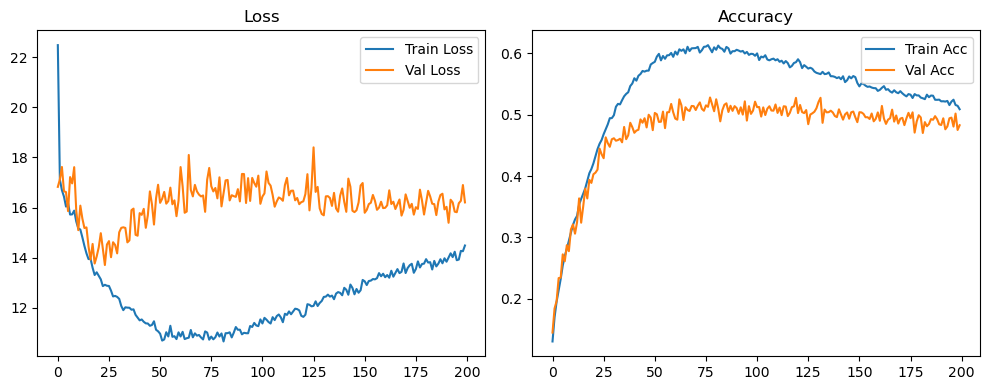

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:02<00:05,  2.55s/it]

Evaluation:  67%|██████▋   | 2/3 [00:05<00:02,  2.54s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  1.89s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  2.07s/it]

...

Files already downloaded and verified


Files already downloaded and verified


🔄 Resuming from epoch 200


Training: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

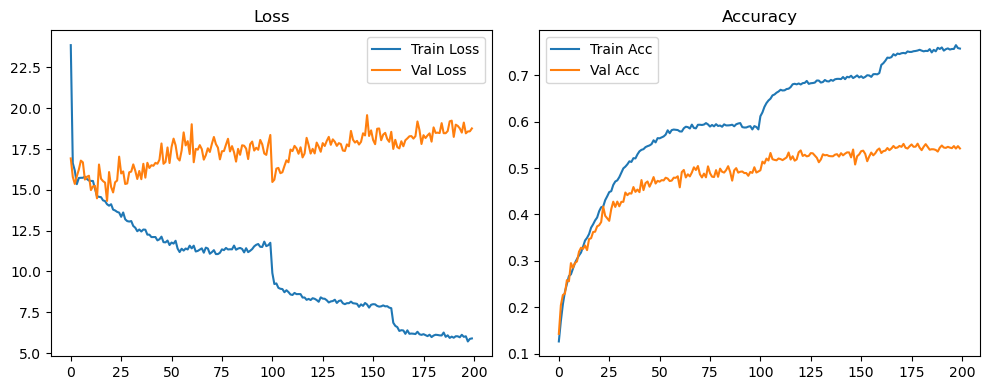

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:02<00:05,  2.54s/it]

Evaluation:  67%|██████▋   | 2/3 [00:05<00:02,  2.53s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  1.89s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  2.06s/it]

...

Files already downloaded and verified


Files already downloaded and verified


🔄 Resuming from epoch 200


Training: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

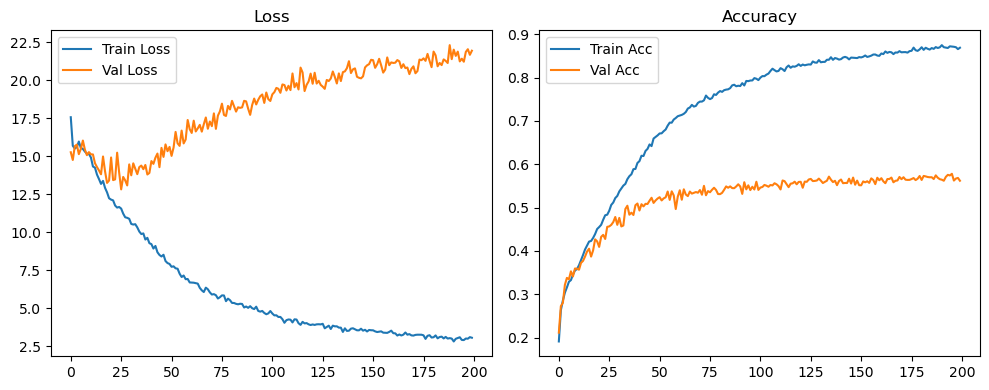

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:02<00:05,  2.66s/it]

Evaluation:  67%|██████▋   | 2/3 [00:05<00:02,  2.60s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  1.92s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  2.11s/it]

...

Files already downloaded and verified


Files already downloaded and verified


🔄 Resuming from epoch 200


Training: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

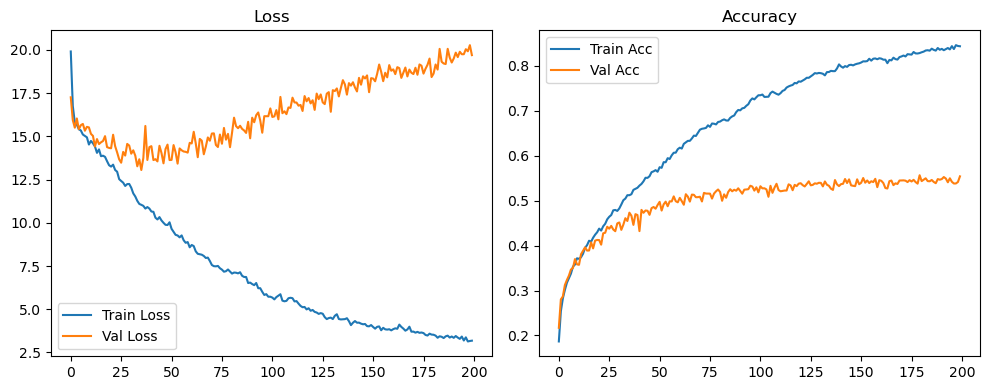

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:02<00:05,  2.54s/it]

Evaluation:  67%|██████▋   | 2/3 [00:05<00:02,  2.54s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  1.89s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  2.07s/it]

...

Files already downloaded and verified


Files already downloaded and verified


🔄 Resuming from epoch 200


Training: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

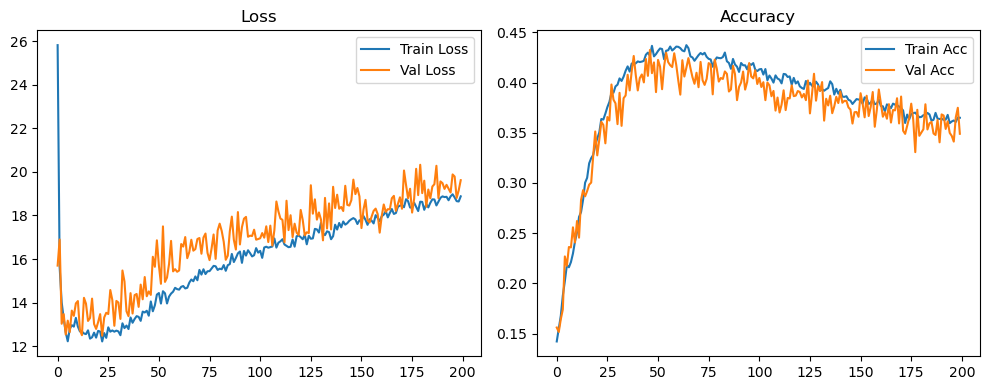

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:02<00:05,  2.54s/it]

Evaluation:  67%|██████▋   | 2/3 [00:05<00:02,  2.54s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  1.89s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  2.06s/it]

...

Files already downloaded and verified


Files already downloaded and verified


🔄 Resuming from epoch 200


Training: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

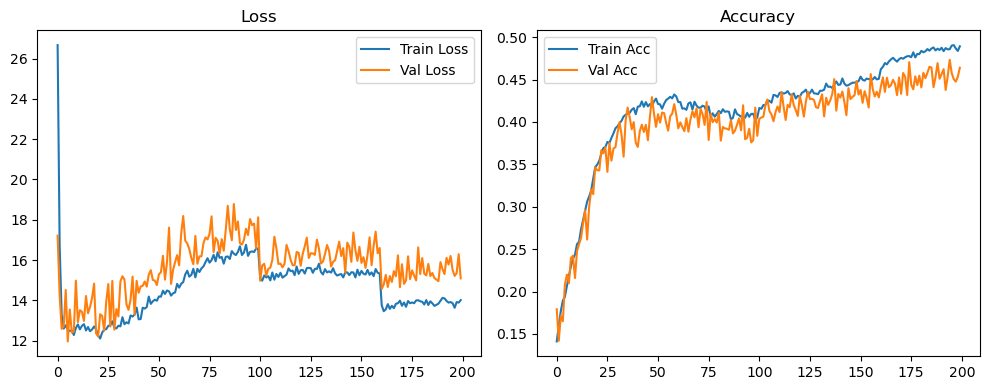

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:02<00:05,  2.54s/it]

Evaluation:  67%|██████▋   | 2/3 [00:05<00:02,  2.54s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  1.89s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  2.07s/it]

...

Files already downloaded and verified


Files already downloaded and verified


🔄 Resuming from epoch 200


Training: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

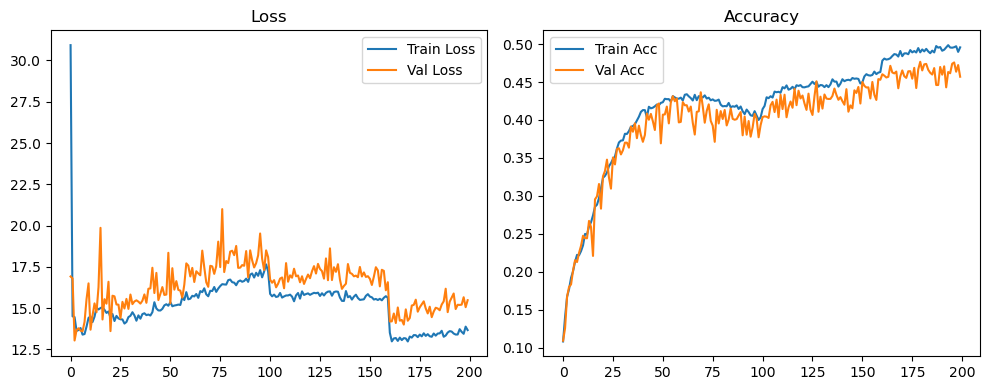

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:02<00:05,  2.69s/it]

Evaluation:  67%|██████▋   | 2/3 [00:05<00:02,  2.60s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  1.92s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  2.11s/it]

...

Files already downloaded and verified


Files already downloaded and verified


🔄 Resuming from epoch 200


Training: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

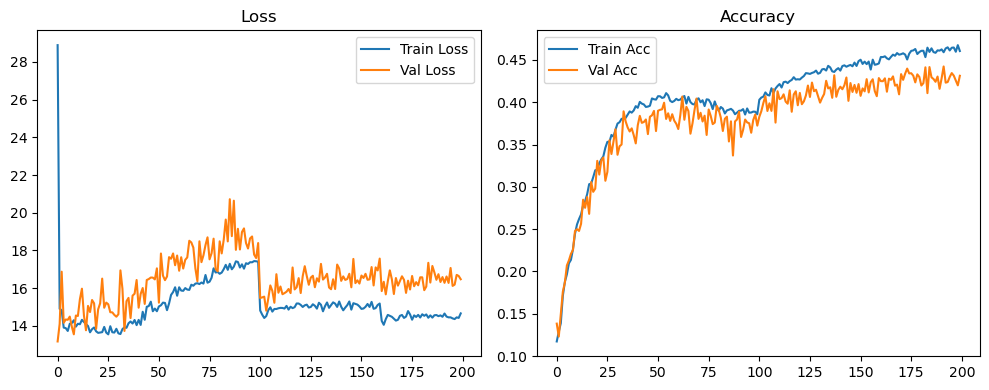

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:02<00:05,  2.55s/it]

Evaluation:  67%|██████▋   | 2/3 [00:05<00:02,  2.54s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  1.89s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  2.07s/it]

...

Files already downloaded and verified


Files already downloaded and verified


🔄 Resuming from epoch 200


Training: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

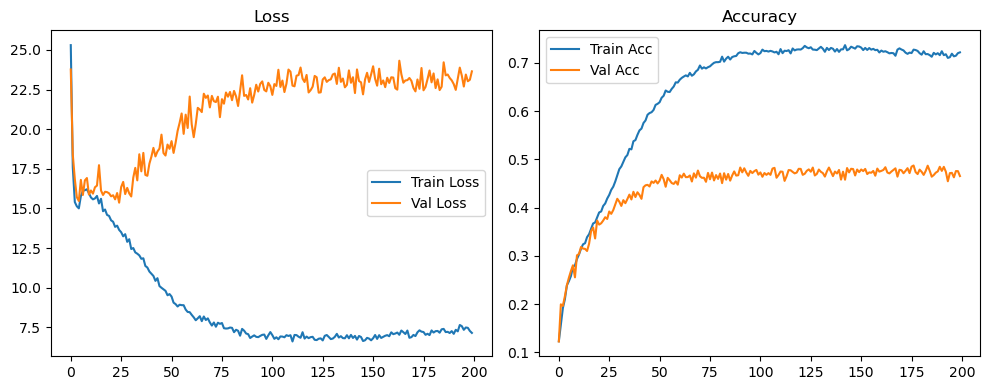

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:02<00:05,  2.55s/it]

Evaluation:  67%|██████▋   | 2/3 [00:05<00:02,  2.54s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  1.89s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  2.07s/it]

...

Files already downloaded and verified


Files already downloaded and verified


🔄 Resuming from epoch 200


Training: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

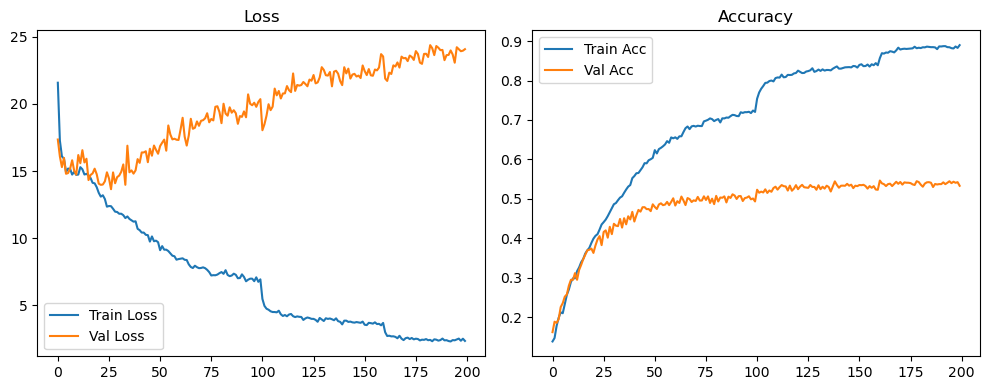

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:02<00:05,  2.54s/it]

Evaluation:  67%|██████▋   | 2/3 [00:05<00:02,  2.61s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  1.93s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  2.10s/it]

...

Files already downloaded and verified


Files already downloaded and verified


🔄 Resuming from epoch 200


Training: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

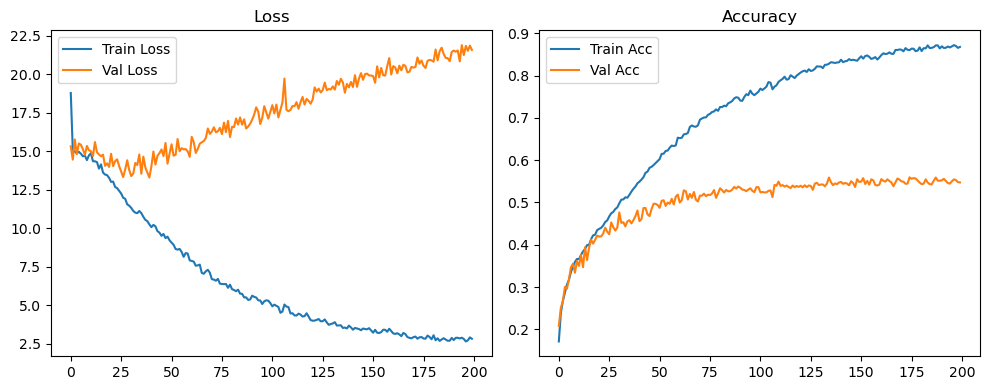

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:02<00:05,  2.54s/it]

Evaluation:  67%|██████▋   | 2/3 [00:05<00:02,  2.53s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  1.89s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  2.06s/it]

...

Files already downloaded and verified


Files already downloaded and verified


🔄 Resuming from epoch 200


Training: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

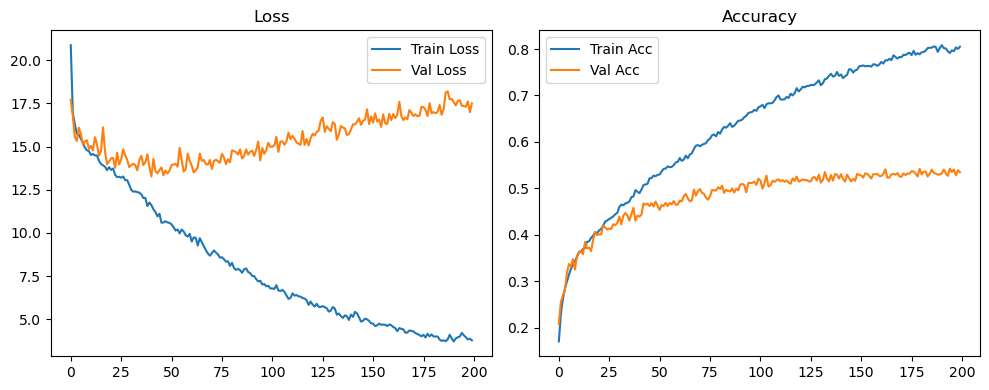

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:02<00:05,  2.53s/it]

Evaluation:  67%|██████▋   | 2/3 [00:05<00:02,  2.53s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  1.89s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  2.06s/it]

...

| LR: 0.001 | Train Acc: 0.4844 | Val Acc: 0.4574 |:  99%|█████████▉| 192/193 [6:21:40<01:59, 119.91s/it]

| LR: 0.001 | Train Acc: 0.4943 | Val Acc: 0.4731 |:  99%|█████████▉| 192/193 [6:23:40<01:59, 119.91s/it]

| LR: 0.001 | Train Acc: 0.4943 | Val Acc: 0.4731 |:  99%|█████████▉| 192/193 [6:23:40<01:59, 119.91s/it]

| LR: 0.001 | Train Acc: 0.4943 | Val Acc: 0.4731 |: 100%|██████████| 193/193 [6:23:40<00:00, 119.95s/it]

| LR: 0.001 | Train Acc: 0.4943 | Val Acc: 0.4731 |: 100%|██████████| 193/193 [6:23:40<00:00, 119.28s/it]

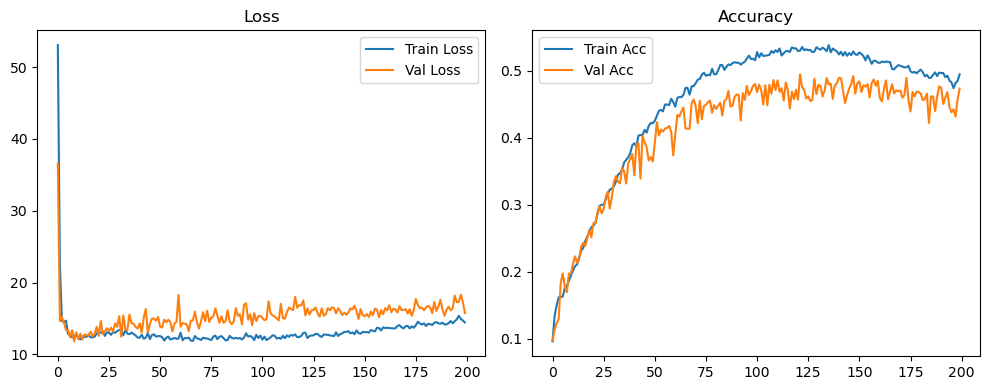

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:02<00:05,  2.56s/it]

Evaluation:  67%|██████▋   | 2/3 [00:05<00:02,  2.56s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  1.90s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  2.08s/it]

...

| LR: 0.000 | Train Acc: 0.6830 | Val Acc: 0.5532 |: 100%|█████████▉| 199/200 [6:35:53<01:59, 119.43s/it]

| LR: 0.000 | Train Acc: 0.6808 | Val Acc: 0.5500 |: 100%|█████████▉| 199/200 [6:37:52<01:59, 119.43s/it]

| LR: 0.000 | Train Acc: 0.6808 | Val Acc: 0.5500 |: 100%|█████████▉| 199/200 [6:37:52<01:59, 119.43s/it]

| LR: 0.000 | Train Acc: 0.6808 | Val Acc: 0.5500 |: 100%|██████████| 200/200 [6:37:52<00:00, 119.49s/it]

| LR: 0.000 | Train Acc: 0.6808 | Val Acc: 0.5500 |: 100%|██████████| 200/200 [6:37:52<00:00, 119.36s/it]

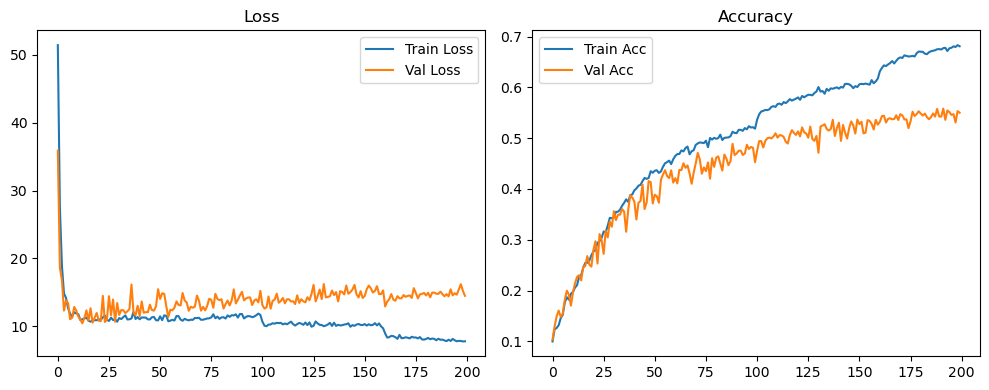

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:02<00:05,  2.58s/it]

Evaluation:  67%|██████▋   | 2/3 [00:05<00:02,  2.66s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  1.96s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  2.14s/it]

...

| LR: 0.000 | Train Acc: 0.7397 | Val Acc: 0.5496 |: 100%|█████████▉| 199/200 [6:36:18<01:59, 119.44s/it]

| LR: 0.000 | Train Acc: 0.7362 | Val Acc: 0.5464 |: 100%|█████████▉| 199/200 [6:38:17<01:59, 119.44s/it]

| LR: 0.000 | Train Acc: 0.7362 | Val Acc: 0.5464 |: 100%|█████████▉| 199/200 [6:38:17<01:59, 119.44s/it]

| LR: 0.000 | Train Acc: 0.7362 | Val Acc: 0.5464 |: 100%|██████████| 200/200 [6:38:18<00:00, 119.42s/it]

| LR: 0.000 | Train Acc: 0.7362 | Val Acc: 0.5464 |: 100%|██████████| 200/200 [6:38:18<00:00, 119.49s/it]

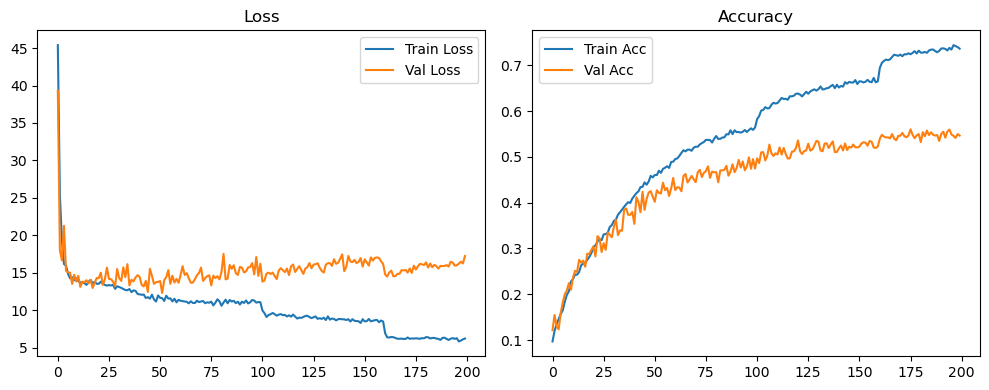

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:02<00:05,  2.57s/it]

Evaluation:  67%|██████▋   | 2/3 [00:05<00:02,  2.56s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  1.91s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  2.08s/it]

...

| LR: 0.000 | Train Acc: 0.6481 | Val Acc: 0.5392 |: 100%|█████████▉| 199/200 [6:36:14<01:59, 119.45s/it]

| LR: 0.000 | Train Acc: 0.6486 | Val Acc: 0.5352 |: 100%|█████████▉| 199/200 [6:38:13<01:59, 119.45s/it]

| LR: 0.000 | Train Acc: 0.6486 | Val Acc: 0.5352 |: 100%|█████████▉| 199/200 [6:38:13<01:59, 119.45s/it]

| LR: 0.000 | Train Acc: 0.6486 | Val Acc: 0.5352 |: 100%|██████████| 200/200 [6:38:13<00:00, 119.43s/it]

| LR: 0.000 | Train Acc: 0.6486 | Val Acc: 0.5352 |: 100%|██████████| 200/200 [6:38:13<00:00, 119.47s/it]

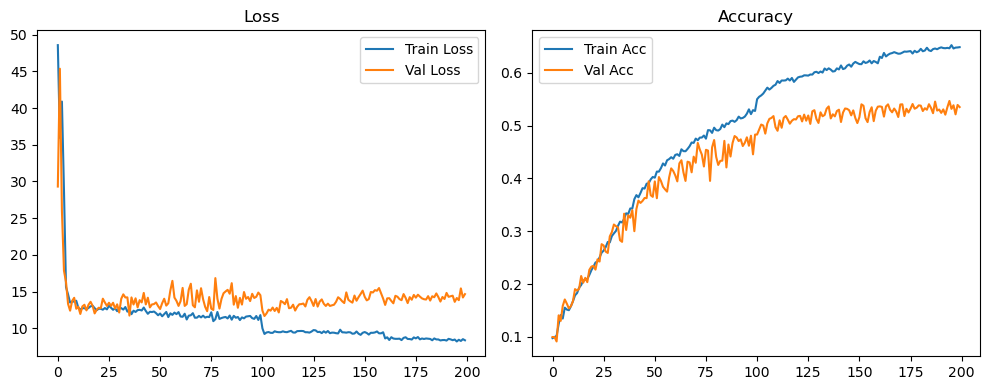

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:02<00:05,  2.57s/it]

Evaluation:  67%|██████▋   | 2/3 [00:05<00:02,  2.56s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  1.91s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  2.08s/it]

...

| LR: 0.001 | Train Acc: 0.8090 | Val Acc: 0.4892 |: 100%|█████████▉| 199/200 [6:36:24<02:00, 120.06s/it]

| LR: 0.001 | Train Acc: 0.8046 | Val Acc: 0.4932 |: 100%|█████████▉| 199/200 [6:38:24<02:00, 120.06s/it]

| LR: 0.001 | Train Acc: 0.8046 | Val Acc: 0.4932 |: 100%|█████████▉| 199/200 [6:38:24<02:00, 120.06s/it]

| LR: 0.001 | Train Acc: 0.8046 | Val Acc: 0.4932 |: 100%|██████████| 200/200 [6:38:24<00:00, 120.02s/it]

| LR: 0.001 | Train Acc: 0.8046 | Val Acc: 0.4932 |: 100%|██████████| 200/200 [6:38:24<00:00, 119.52s/it]

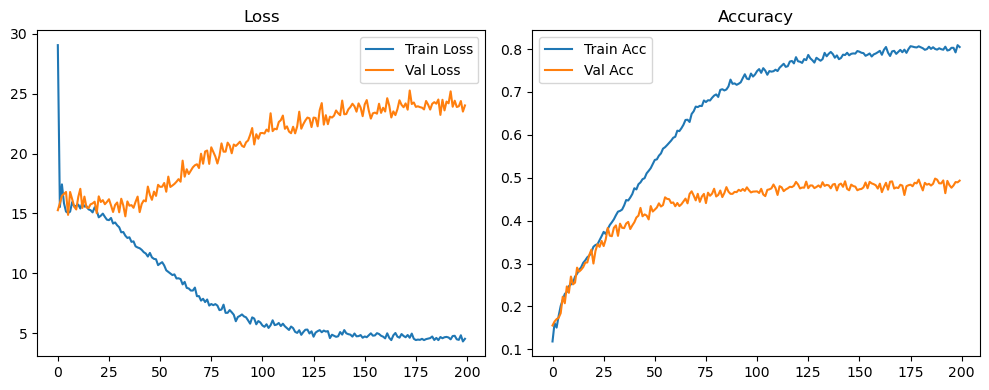

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:02<00:05,  2.60s/it]

Evaluation:  67%|██████▋   | 2/3 [00:05<00:02,  2.60s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  1.94s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  2.12s/it]

...

| LR: 0.000 | Train Acc: 0.8869 | Val Acc: 0.4991 |: 100%|█████████▉| 199/200 [6:37:25<01:59, 119.42s/it]

| LR: 0.000 | Train Acc: 0.8882 | Val Acc: 0.5020 |: 100%|█████████▉| 199/200 [6:39:25<01:59, 119.42s/it]

| LR: 0.000 | Train Acc: 0.8882 | Val Acc: 0.5020 |: 100%|█████████▉| 199/200 [6:39:25<01:59, 119.42s/it]

| LR: 0.000 | Train Acc: 0.8882 | Val Acc: 0.5020 |: 100%|██████████| 200/200 [6:39:25<00:00, 119.41s/it]

| LR: 0.000 | Train Acc: 0.8882 | Val Acc: 0.5020 |: 100%|██████████| 200/200 [6:39:25<00:00, 119.83s/it]

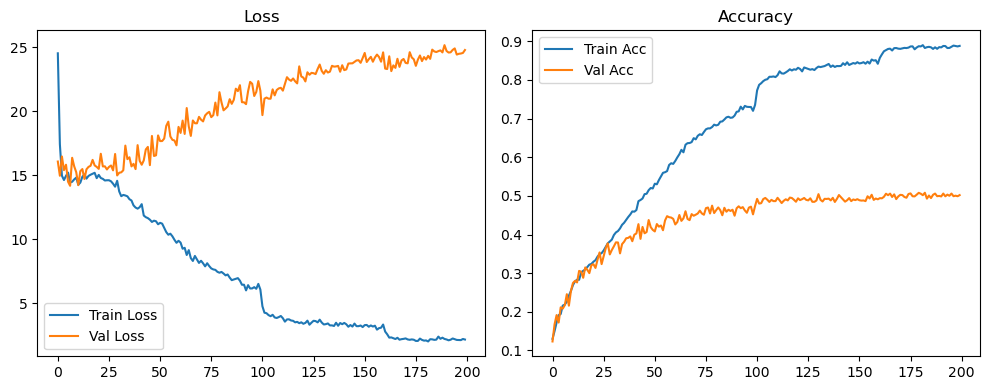

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:02<00:05,  2.56s/it]

Evaluation:  67%|██████▋   | 2/3 [00:05<00:02,  2.56s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  1.91s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  2.08s/it]

...

| LR: 0.000 | Train Acc: 0.8513 | Val Acc: 0.5469 |: 100%|█████████▉| 199/200 [6:36:32<01:59, 119.48s/it]

| LR: 0.000 | Train Acc: 0.8560 | Val Acc: 0.5295 |: 100%|█████████▉| 199/200 [6:38:31<01:59, 119.48s/it]

| LR: 0.000 | Train Acc: 0.8560 | Val Acc: 0.5295 |: 100%|█████████▉| 199/200 [6:38:31<01:59, 119.48s/it]

| LR: 0.000 | Train Acc: 0.8560 | Val Acc: 0.5295 |: 100%|██████████| 200/200 [6:38:32<00:00, 119.47s/it]

| LR: 0.000 | Train Acc: 0.8560 | Val Acc: 0.5295 |: 100%|██████████| 200/200 [6:38:32<00:00, 119.56s/it]

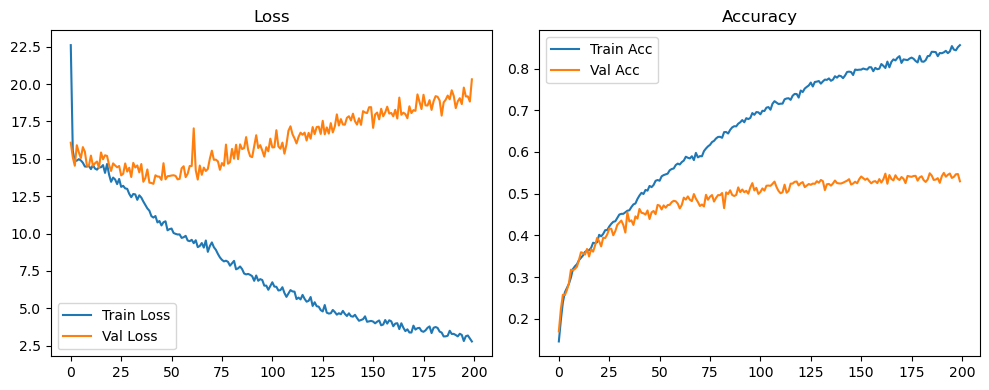

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:02<00:05,  2.56s/it]

Evaluation:  67%|██████▋   | 2/3 [00:05<00:02,  2.56s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  1.90s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  2.08s/it]

...

| LR: 0.000 | Train Acc: 0.7403 | Val Acc: 0.5264 |: 100%|█████████▉| 199/200 [6:36:12<01:59, 119.47s/it]

| LR: 0.000 | Train Acc: 0.7396 | Val Acc: 0.5350 |: 100%|█████████▉| 199/200 [6:38:12<01:59, 119.47s/it]

| LR: 0.000 | Train Acc: 0.7396 | Val Acc: 0.5350 |: 100%|█████████▉| 199/200 [6:38:12<01:59, 119.47s/it]

| LR: 0.000 | Train Acc: 0.7396 | Val Acc: 0.5350 |: 100%|██████████| 200/200 [6:38:12<00:00, 119.44s/it]

| LR: 0.000 | Train Acc: 0.7396 | Val Acc: 0.5350 |: 100%|██████████| 200/200 [6:38:12<00:00, 119.46s/it]

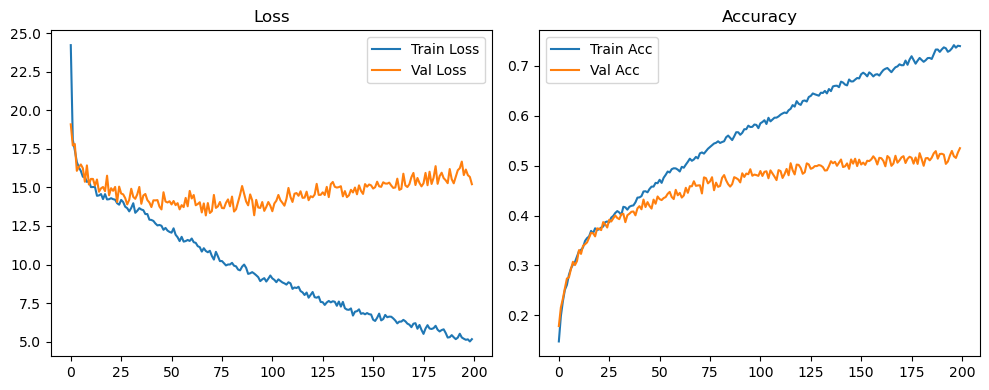

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:02<00:05,  2.56s/it]

Evaluation:  67%|██████▋   | 2/3 [00:05<00:02,  2.55s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  1.90s/it]

Evaluation: 100%|██████████| 3/3 [00:06<00:00,  2.08s/it]

Original Model Final Test Loss: 15.5995 Accuracy: 0.5179


🏆 Best Config: batch256_lr0.0002_0.0002_0.0002_dp0.0 Accuracy: 0.5580


In [11]:
root_path = "CNV_BiKA"
epochs = 200
#batch_sizes = [128, 256, 512, 1024]
#dropout_rates = [0.0, 0.2, 0.5]
batch_sizes = [256, 512, 1024]
dropout_rates = [0.0]
lr_pool = [0.001, 0.0005, 0.0002, 0.0001]

Hyperparameter_searching(root_path, epochs, batch_sizes, lr_pool, dropout_rates)